In [ ]:
import pandas as pd
import numpy as np
import datetime as dt
seoul1 = pd.read_csv("/mnt/nvme/hybrid/SCI/기온 데이터/seoul.csv")
chungbuk1 = pd.read_csv("/mnt/nvme/hybrid/SCI/기온 데이터/chungbuk.csv")
chungnam1 = pd.read_csv("/mnt/nvme/hybrid/SCI/기온 데이터/chungnam.csv")
gyeongi1 = pd.read_csv("/mnt/nvme/hybrid/SCI/기온 데이터/gyeongi.csv")
gyongbuk1 = pd.read_csv("/mnt/nvme/hybrid/SCI/기온 데이터/gyongbuk.csv")
gyongnam1 = pd.read_csv("/mnt/nvme/hybrid/SCI/기온 데이터/gyongnam.csv")
incheon1 = pd.read_csv("/mnt/nvme/hybrid/SCI/기온 데이터/incheon.csv")
jeonam1 = pd.read_csv("/mnt/nvme/hybrid/SCI/기온 데이터/jeonam.csv")
jeonbuk1 = pd.read_csv("/mnt/nvme/hybrid/SCI/기온 데이터/jeonbuk.csv")
other1 = pd.read_csv("/mnt/nvme/hybrid/SCI/기온 데이터/other.csv")
jeju1 = pd.read_csv("/mnt/nvme/hybrid/SCI/기후데이터/jeju.csv")
gangwon1 = pd.read_csv("/mnt/nvme/hybrid/SCI/기온 데이터/gangwon.csv")

/tmp/ipykernel_3682757/2020576947.py:11: DtypeWarning: Columns (28) have mixed types. Specify dtype option on import or set low_memory=False.
  jeonam1 = pd.read_csv("/mnt/nvme/hybrid/SCI/기온 데이터/jeonam.csv")


In [ ]:
# 각 지역의 결측치가 몇개 정도 있는지 연도별로 생성하는 함수 구현
def NA_interpolate(data, columns):
    na_columns = np.unique(data[data[columns].isnull()]["stnNm"])
    data["tm"] = pd.to_datetime(data["tm"])
    data = data[data["tm"]>"2021-01-01"]
    
    # 결측치 개수를 보관하기 위한 df
    na_table = pd.DataFrame()

    for i in na_columns:
        print(f"{i}의 결측치 보간을 시작합니다.")
        sample = data[data["stnNm"] == i].copy()
        sample1 = sample[sample[columns].isnull()]

        sample = sample.sort_values(by="tm")
        sample.set_index("tm", inplace=True)

        sample[f"spline_{columns}"] = sample[columns].interpolate()
        print(f"{i}의 결측치 보간이 종료되었습니다. 결측치 개수는 {sample1.groupby('stnNm').size()}")
        test = sample1.groupby('stnNm').size()
        print(test)
        # na_table[""]

        print(sample[f"spline_{columns}"])
        data.loc[data["stnNm"] == i, f"spline_{columns}"] = sample[f"spline_{columns}"].values
        print("=============================================")
    
    return data

In [ ]:
def NA_interpolate(data, columns):
    na_columns = np.unique(data[data[columns].isnull()]["stnNm"])
    data["tm"] = pd.to_datetime(data["tm"])
    data = data[data["tm"] > "2021-01-01"]
    
    # 결측치 개수를 누적할 DataFrame
    na_table = pd.DataFrame()

    for i in na_columns:
        print(f"{i}의 결측치 보간을 시작합니다.")
        sample = data[data["stnNm"] == i].copy()
        sample1 = sample[sample[columns].isnull()]

        # 연도별 결측치 개수 계산
        sample1["year"] = sample1["tm"].dt.year
        yearly_na = sample1.groupby(["stnNm", "year"]).size().reset_index(name="missing_count")
        
        # 누적 저장
        na_table = pd.concat([na_table, yearly_na], ignore_index=True)

        sample = sample.sort_values(by="tm")
        sample.set_index("tm", inplace=True)

        sample[f"spline_{columns}"] = sample[columns].interpolate()
        print(f"{i}의 결측치 보간이 종료되었습니다.")
        print(sample[f"spline_{columns}"])
        
        data.loc[data["stnNm"] == i, f"spline_{columns}"] = sample[f"spline_{columns}"].values
        print("=============================================")
    
    # 피벗 테이블 형식으로 보기 좋게 출력 (선택)
    pivot_table = na_table.pivot_table(
        index="stnNm",
        columns="year",
        values="missing_count",
        fill_value=0
    )

    return data, pivot_table


In [ ]:
_, jeju_table_ta = NA_interpolate(jeju1, "ta")
_, table = NA_interpolate(jeju1, "ta")

고산의 결측치 보간을 시작합니다.
고산의 결측치 보간이 종료되었습니다.
tm
2021-01-01 01:00:00     4.5
2021-01-01 02:00:00     4.4
2021-01-01 03:00:00     4.3
2021-01-01 04:00:00     4.5
2021-01-01 05:00:00     4.3
                       ... 
2024-10-31 19:00:00    19.5
2024-10-31 20:00:00    17.8
2024-10-31 21:00:00    17.6
2024-10-31 22:00:00    18.3
2024-10-31 23:00:00    19.0
Name: spline_ta, Length: 31487, dtype: float64
서귀포의 결측치 보간을 시작합니다.
서귀포의 결측치 보간이 종료되었습니다.
tm
2021-01-01 01:00:00     3.4
2021-01-01 02:00:00     3.3
2021-01-01 03:00:00     3.2
2021-01-01 04:00:00     2.9
2021-01-01 05:00:00     3.4
                       ... 
2024-10-31 19:00:00    19.1
2024-10-31 20:00:00    18.9
2024-10-31 21:00:00    19.6
2024-10-31 22:00:00    20.1
2024-10-31 23:00:00    20.1
Name: spline_ta, Length: 31487, dtype: float64
성산의 결측치 보간을 시작합니다.
성산의 결측치 보간이 종료되었습니다.
tm
2021-01-01 01:00:00     3.3
2021-01-01 02:00:00     3.1
2021-01-01 03:00:00     2.7
2021-01-01 04:00:00     2.9
2021-01-01 05:00:00     1.6
                   

/tmp/ipykernel_3682757/1550930004.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample1["year"] = sample1["tm"].dt.year
/tmp/ipykernel_3682757/1550930004.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[data["stnNm"] == i, f"spline_{columns}"] = sample[f"spline_{columns}"].values
/tmp/ipykernel_3682757/1550930004.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in th

성산의 결측치 보간을 시작합니다.
성산의 결측치 보간이 종료되었습니다.
tm
2021-01-01 01:00:00     3.3
2021-01-01 02:00:00     3.1
2021-01-01 03:00:00     2.7
2021-01-01 04:00:00     2.9
2021-01-01 05:00:00     1.6
                       ... 
2024-10-31 19:00:00    18.7
2024-10-31 20:00:00    18.8
2024-10-31 21:00:00    19.7
2024-10-31 22:00:00    20.5
2024-10-31 23:00:00    20.3
Name: spline_ta, Length: 31487, dtype: float64
제주의 결측치 보간을 시작합니다.
제주의 결측치 보간이 종료되었습니다.
tm
2021-01-01 01:00:00     4.3
2021-01-01 02:00:00     4.2
2021-01-01 03:00:00     4.3
2021-01-01 04:00:00     4.2
2021-01-01 05:00:00     4.4
                       ... 
2024-10-31 19:00:00    20.6
2024-10-31 20:00:00    19.7
2024-10-31 21:00:00    19.6
2024-10-31 22:00:00    19.2
2024-10-31 23:00:00    19.5
Name: spline_ta, Length: 31487, dtype: float64


/tmp/ipykernel_3682757/1550930004.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample1["year"] = sample1["tm"].dt.year
/tmp/ipykernel_3682757/1550930004.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample1["year"] = sample1["tm"].dt.year


In [ ]:
_, gangwon_table_ta = NA_interpolate(gangwon1, "ta")
_, gangwon_table_hm = NA_interpolate(gangwon1, "hm")

강릉의 결측치 보간을 시작합니다.
강릉의 결측치 보간이 종료되었습니다.
tm
2021-01-01 01:00:00    -5.2
2021-01-01 02:00:00    -5.6
2021-01-01 03:00:00    -6.0
2021-01-01 04:00:00    -6.1
2021-01-01 05:00:00    -6.0
                       ... 
2024-10-31 19:00:00    16.4
2024-10-31 20:00:00    15.3
2024-10-31 21:00:00    14.9
2024-10-31 22:00:00    14.1
2024-10-31 23:00:00    13.4
Name: spline_ta, Length: 26735, dtype: float64
대관령의 결측치 보간을 시작합니다.
대관령의 결측치 보간이 종료되었습니다.
tm
2021-01-01 01:00:00   -14.0
2021-01-01 02:00:00   -14.4
2021-01-01 03:00:00   -14.4
2021-01-01 04:00:00   -14.0
2021-01-01 05:00:00   -13.4
                       ... 
2024-10-31 19:00:00     8.9
2024-10-31 20:00:00     7.3
2024-10-31 21:00:00     5.1
2024-10-31 22:00:00     4.8
2024-10-31 23:00:00     3.5
Name: spline_ta, Length: 26735, dtype: float64
동해의 결측치 보간을 시작합니다.
동해의 결측치 보간이 종료되었습니다.
tm
2021-01-01 01:00:00    -4.4
2021-01-01 02:00:00    -4.5
2021-01-01 03:00:00    -4.6
2021-01-01 04:00:00    -4.7
2021-01-01 05:00:00    -5.0
                   

/tmp/ipykernel_3682757/1550930004.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample1["year"] = sample1["tm"].dt.year
/tmp/ipykernel_3682757/1550930004.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[data["stnNm"] == i, f"spline_{columns}"] = sample[f"spline_{columns}"].values
/tmp/ipykernel_3682757/1550930004.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in th

영월의 결측치 보간을 시작합니다.
영월의 결측치 보간이 종료되었습니다.
tm
2021-01-01 01:00:00    -7.9
2021-01-01 02:00:00    -9.3
2021-01-01 03:00:00   -10.3
2021-01-01 04:00:00   -10.8
2021-01-01 05:00:00   -11.6
                       ... 
2024-10-31 19:00:00    12.9
2024-10-31 20:00:00    12.6
2024-10-31 21:00:00    11.1
2024-10-31 22:00:00    10.2
2024-10-31 23:00:00     9.5
Name: spline_ta, Length: 26735, dtype: float64
원주의 결측치 보간을 시작합니다.
원주의 결측치 보간이 종료되었습니다.
tm
2021-01-01 01:00:00    -8.9
2021-01-01 02:00:00    -9.4
2021-01-01 03:00:00    -9.9
2021-01-01 04:00:00   -10.1
2021-01-01 05:00:00   -11.1
                       ... 
2024-10-31 19:00:00    15.5
2024-10-31 20:00:00    14.2
2024-10-31 21:00:00    13.5
2024-10-31 22:00:00    12.3
2024-10-31 23:00:00    11.5
Name: spline_ta, Length: 26735, dtype: float64
인제의 결측치 보간을 시작합니다.
인제의 결측치 보간이 종료되었습니다.
tm
2021-01-01 01:00:00    -8.4
2021-01-01 02:00:00    -9.6
2021-01-01 03:00:00   -11.9
2021-01-01 04:00:00   -12.5
2021-01-01 05:00:00    -9.3
                     

/tmp/ipykernel_3682757/1550930004.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample1["year"] = sample1["tm"].dt.year
/tmp/ipykernel_3682757/1550930004.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample1["year"] = sample1["tm"].dt.year
/tmp/ipykernel_3682757/1550930004.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pand

춘천의 결측치 보간을 시작합니다.
춘천의 결측치 보간이 종료되었습니다.
tm
2021-01-01 01:00:00    -9.0
2021-01-01 02:00:00   -10.4
2021-01-01 03:00:00   -11.7
2021-01-01 04:00:00   -12.3
2021-01-01 05:00:00   -13.2
                       ... 
2024-10-31 19:00:00    14.2
2024-10-31 20:00:00    12.8
2024-10-31 21:00:00    11.5
2024-10-31 22:00:00    10.3
2024-10-31 23:00:00    10.0
Name: spline_ta, Length: 26735, dtype: float64
태백의 결측치 보간을 시작합니다.
태백의 결측치 보간이 종료되었습니다.
tm
2021-01-01 01:00:00   -10.1
2021-01-01 02:00:00   -10.2
2021-01-01 03:00:00   -10.6
2021-01-01 04:00:00   -10.5
2021-01-01 05:00:00   -10.1
                       ... 
2024-10-31 19:00:00    10.3
2024-10-31 20:00:00     8.7
2024-10-31 21:00:00     7.6
2024-10-31 22:00:00     6.5
2024-10-31 23:00:00     6.1
Name: spline_ta, Length: 26735, dtype: float64
강릉의 결측치 보간을 시작합니다.
강릉의 결측치 보간이 종료되었습니다.
tm
2021-01-01 01:00:00    38.0
2021-01-01 02:00:00    39.0
2021-01-01 03:00:00    37.0
2021-01-01 04:00:00    36.0
2021-01-01 05:00:00    37.0
                     

/tmp/ipykernel_3682757/1550930004.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample1["year"] = sample1["tm"].dt.year
/tmp/ipykernel_3682757/1550930004.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample1["year"] = sample1["tm"].dt.year
/tmp/ipykernel_3682757/1550930004.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pand

대관령의 결측치 보간을 시작합니다.
대관령의 결측치 보간이 종료되었습니다.
tm
2021-01-01 01:00:00    72.0
2021-01-01 02:00:00    70.0
2021-01-01 03:00:00    64.0
2021-01-01 04:00:00    59.0
2021-01-01 05:00:00    58.0
                       ... 
2024-10-31 19:00:00    93.0
2024-10-31 20:00:00    95.0
2024-10-31 21:00:00    95.0
2024-10-31 22:00:00    96.0
2024-10-31 23:00:00    96.0
Name: spline_hm, Length: 26735, dtype: float64
동해의 결측치 보간을 시작합니다.
동해의 결측치 보간이 종료되었습니다.
tm
2021-01-01 01:00:00    28.0
2021-01-01 02:00:00    28.0
2021-01-01 03:00:00    26.0
2021-01-01 04:00:00    25.0
2021-01-01 05:00:00    28.0
                       ... 
2024-10-31 19:00:00    87.0
2024-10-31 20:00:00    91.0
2024-10-31 21:00:00    92.0
2024-10-31 22:00:00    92.0
2024-10-31 23:00:00    91.0
Name: spline_hm, Length: 26735, dtype: float64
속초의 결측치 보간을 시작합니다.
속초의 결측치 보간이 종료되었습니다.
tm
2021-01-01 01:00:00    30.0
2021-01-01 02:00:00    26.0
2021-01-01 03:00:00    25.0
2021-01-01 04:00:00    25.0
2021-01-01 05:00:00    27.0
                   

/tmp/ipykernel_3682757/1550930004.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample1["year"] = sample1["tm"].dt.year
/tmp/ipykernel_3682757/1550930004.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample1["year"] = sample1["tm"].dt.year
/tmp/ipykernel_3682757/1550930004.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pand

태백의 결측치 보간을 시작합니다.
태백의 결측치 보간이 종료되었습니다.
tm
2021-01-01 01:00:00    44.0
2021-01-01 02:00:00    42.0
2021-01-01 03:00:00    44.0
2021-01-01 04:00:00    44.0
2021-01-01 05:00:00    50.0
                       ... 
2024-10-31 19:00:00    84.0
2024-10-31 20:00:00    91.0
2024-10-31 21:00:00    93.0
2024-10-31 22:00:00    94.0
2024-10-31 23:00:00    95.0
Name: spline_hm, Length: 26735, dtype: float64
홍성의 결측치 보간을 시작합니다.
홍성의 결측치 보간이 종료되었습니다.
tm
2021-01-01 01:00:00    91.0
2021-01-01 02:00:00    92.0
2021-01-01 03:00:00    93.0
2021-01-01 04:00:00    93.0
2021-01-01 05:00:00    92.0
                       ... 
2024-10-31 19:00:00    76.0
2024-10-31 20:00:00    83.0
2024-10-31 21:00:00    89.0
2024-10-31 22:00:00    91.0
2024-10-31 23:00:00    94.0
Name: spline_hm, Length: 26735, dtype: float64


/tmp/ipykernel_3682757/1550930004.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample1["year"] = sample1["tm"].dt.year
/tmp/ipykernel_3682757/1550930004.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample1["year"] = sample1["tm"].dt.year


In [ ]:
# 보간 및 연도별 결측치 통계 생성
# _, seoul_table_ta = NA_interpolate(seoul1, "ta") -> 서울은 없음
# _, seoul_table_hm = NA_interpolate(seoul1, "hm") -> 서울은 없음

_, chungbuk_table_ta = NA_interpolate(chungbuk1, "ta")
_, chungbuk_table_hm = NA_interpolate(chungbuk1, "hm")

_, chungnam_table_ta = NA_interpolate(chungnam1, "ta")
_, chungnam_table_hm = NA_interpolate(chungnam1, "hm")

_, gyeongi_table_ta = NA_interpolate(gyeongi1, "ta")
_, gyeongi_table_hm = NA_interpolate(gyeongi1, "hm")

_, gyongbuk_table_ta = NA_interpolate(gyongbuk1, "ta")
_, gyongbuk_table_hm = NA_interpolate(gyongbuk1, "hm")

_, gyongnam_table_ta = NA_interpolate(gyongnam1, "ta")
_, gyongnam_table_hm = NA_interpolate(gyongnam1, "hm")

# _, incheon_table_ta = NA_interpolate(incheon1, "ta")
# _, incheon_table_hm = NA_interpolate(incheon1, "hm")

_, jeonam_table_ta = NA_interpolate(jeonam1, "ta")
_, jeonam_table_hm = NA_interpolate(jeonam1, "hm")

_, jeonbuk_table_ta = NA_interpolate(jeonbuk1, "ta")
_, jeonbuk_table_hm = NA_interpolate(jeonbuk1, "hm")

_, other_table_ta = NA_interpolate(other1, "ta")
_, other_table_hm = NA_interpolate(other1, "hm")

_, jeju_table_ta = NA_interpolate(jeju1, "ta")
_, jeju_table_hm = NA_interpolate(jeju1, "hm")

보은의 결측치 보간을 시작합니다.
보은의 결측치 보간이 종료되었습니다.
tm
2021-01-01 01:00:00   -11.2
2021-01-01 02:00:00   -11.5
2021-01-01 03:00:00   -11.4
2021-01-01 04:00:00   -12.4
2021-01-01 05:00:00   -12.8
                       ... 
2024-10-31 19:00:00    14.1
2024-10-31 20:00:00    11.6
2024-10-31 21:00:00    11.0
2024-10-31 22:00:00    10.3
2024-10-31 23:00:00    10.1
Name: spline_ta, Length: 26543, dtype: float64
제천의 결측치 보간을 시작합니다.
제천의 결측치 보간이 종료되었습니다.
tm
2021-01-01 01:00:00    -9.7
2021-01-01 02:00:00   -10.1
2021-01-01 03:00:00    -9.6
2021-01-01 04:00:00   -12.1
2021-01-01 05:00:00   -13.0
                       ... 
2024-10-31 19:00:00    11.1
2024-10-31 20:00:00    10.0
2024-10-31 21:00:00     9.0
2024-10-31 22:00:00     8.3
2024-10-31 23:00:00     7.8
Name: spline_ta, Length: 26543, dtype: float64
청주의 결측치 보간을 시작합니다.


/tmp/ipykernel_3682757/1550930004.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample1["year"] = sample1["tm"].dt.year
/tmp/ipykernel_3682757/1550930004.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[data["stnNm"] == i, f"spline_{columns}"] = sample[f"spline_{columns}"].values
/tmp/ipykernel_3682757/1550930004.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in th

청주의 결측치 보간이 종료되었습니다.
tm
2021-01-01 01:00:00    -7.2
2021-01-01 02:00:00    -7.8
2021-01-01 03:00:00    -8.2
2021-01-01 04:00:00    -8.9
2021-01-01 05:00:00    -9.1
                       ... 
2024-10-31 19:00:00    18.2
2024-10-31 20:00:00    17.2
2024-10-31 21:00:00    16.3
2024-10-31 22:00:00    15.3
2024-10-31 23:00:00    14.1
Name: spline_ta, Length: 26543, dtype: float64
추풍령의 결측치 보간을 시작합니다.
추풍령의 결측치 보간이 종료되었습니다.
tm
2021-01-01 01:00:00    -7.0
2021-01-01 02:00:00    -6.8
2021-01-01 03:00:00    -7.0
2021-01-01 04:00:00    -7.4
2021-01-01 05:00:00    -7.2
                       ... 
2024-10-31 19:00:00    13.6
2024-10-31 20:00:00    11.8
2024-10-31 21:00:00    11.7
2024-10-31 22:00:00    11.3
2024-10-31 23:00:00    10.5
Name: spline_ta, Length: 26543, dtype: float64
충주의 결측치 보간을 시작합니다.
충주의 결측치 보간이 종료되었습니다.
tm
2021-01-01 01:00:00    -9.2
2021-01-01 02:00:00   -10.6
2021-01-01 03:00:00   -10.7
2021-01-01 04:00:00   -11.0
2021-01-01 05:00:00   -11.7
                       ... 
2024-10-31

/tmp/ipykernel_3682757/1550930004.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample1["year"] = sample1["tm"].dt.year
/tmp/ipykernel_3682757/1550930004.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample1["year"] = sample1["tm"].dt.year
/tmp/ipykernel_3682757/1550930004.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pand

제천의 결측치 보간이 종료되었습니다.
tm
2021-01-01 01:00:00     74.0
2021-01-01 02:00:00     74.0
2021-01-01 03:00:00     70.0
2021-01-01 04:00:00     80.0
2021-01-01 05:00:00     84.0
                       ...  
2024-10-31 19:00:00     92.0
2024-10-31 20:00:00     95.0
2024-10-31 21:00:00     98.0
2024-10-31 22:00:00    100.0
2024-10-31 23:00:00    100.0
Name: spline_hm, Length: 26543, dtype: float64
청주의 결측치 보간을 시작합니다.
청주의 결측치 보간이 종료되었습니다.
tm
2021-01-01 01:00:00    85.0
2021-01-01 02:00:00    84.0
2021-01-01 03:00:00    84.0
2021-01-01 04:00:00    84.0
2021-01-01 05:00:00    83.0
                       ... 
2024-10-31 19:00:00    53.0
2024-10-31 20:00:00    58.0
2024-10-31 21:00:00    64.0
2024-10-31 22:00:00    68.0
2024-10-31 23:00:00    74.0
Name: spline_hm, Length: 26543, dtype: float64
추풍령의 결측치 보간을 시작합니다.
추풍령의 결측치 보간이 종료되었습니다.
tm
2021-01-01 01:00:00    72.0
2021-01-01 02:00:00    73.0
2021-01-01 03:00:00    73.0
2021-01-01 04:00:00    74.0
2021-01-01 05:00:00    73.0
                       ... 

...

/tmp/ipykernel_3682757/1550930004.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample1["year"] = sample1["tm"].dt.year
/tmp/ipykernel_3682757/1550930004.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[data["stnNm"] == i, f"spline_{columns}"] = sample[f"spline_{columns}"].values
/tmp/ipykernel_3682757/1550930004.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in th

고창의 결측치 보간이 종료되었습니다.
tm
2021-01-01 01:00:00    83.0
2021-01-01 02:00:00    90.0
2021-01-01 03:00:00    93.0
2021-01-01 04:00:00    93.0
2021-01-01 05:00:00    92.0
                       ... 
2024-10-31 19:00:00    71.0
2024-10-31 20:00:00    67.0
2024-10-31 21:00:00    75.0
2024-10-31 22:00:00    79.0
2024-10-31 23:00:00    86.0
Name: spline_hm, Length: 28919, dtype: float64
광주의 결측치 보간을 시작합니다.
광주의 결측치 보간이 종료되었습니다.
tm
2021-01-01 01:00:00    83.0
2021-01-01 02:00:00    81.0
2021-01-01 03:00:00    86.0
2021-01-01 04:00:00    87.0
2021-01-01 05:00:00    93.0
                       ... 
2024-10-31 19:00:00    69.0
2024-10-31 20:00:00    70.0
2024-10-31 21:00:00    77.0
2024-10-31 22:00:00    79.0
2024-10-31 23:00:00    81.0
Name: spline_hm, Length: 28919, dtype: float64
대전의 결측치 보간을 시작합니다.
대전의 결측치 보간이 종료되었습니다.
tm
2021-01-01 01:00:00    90.0
2021-01-01 02:00:00    91.0
2021-01-01 03:00:00    90.0
2021-01-01 04:00:00    90.0
2021-01-01 05:00:00    91.0
                       ... 
2024-10-31 1

/tmp/ipykernel_3682757/1550930004.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[data["stnNm"] == i, f"spline_{columns}"] = sample[f"spline_{columns}"].values
/tmp/ipykernel_3682757/1550930004.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample1["year"] = sample1["tm"].dt.year
/tmp/ipykernel_3682757/1550930004.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in th

서귀포의 결측치 보간이 종료되었습니다.
tm
2021-01-01 01:00:00     3.4
2021-01-01 02:00:00     3.3
2021-01-01 03:00:00     3.2
2021-01-01 04:00:00     2.9
2021-01-01 05:00:00     3.4
                       ... 
2024-10-31 19:00:00    19.1
2024-10-31 20:00:00    18.9
2024-10-31 21:00:00    19.6
2024-10-31 22:00:00    20.1
2024-10-31 23:00:00    20.1
Name: spline_ta, Length: 31487, dtype: float64
성산의 결측치 보간을 시작합니다.
성산의 결측치 보간이 종료되었습니다.
tm
2021-01-01 01:00:00     3.3
2021-01-01 02:00:00     3.1
2021-01-01 03:00:00     2.7
2021-01-01 04:00:00     2.9
2021-01-01 05:00:00     1.6
                       ... 
2024-10-31 19:00:00    18.7
2024-10-31 20:00:00    18.8
2024-10-31 21:00:00    19.7
2024-10-31 22:00:00    20.5
2024-10-31 23:00:00    20.3
Name: spline_ta, Length: 31487, dtype: float64
제주의 결측치 보간을 시작합니다.
제주의 결측치 보간이 종료되었습니다.
tm
2021-01-01 01:00:00     4.3
2021-01-01 02:00:00     4.2
2021-01-01 03:00:00     4.3
2021-01-01 04:00:00     4.2
2021-01-01 05:00:00     4.4
                       ... 
2024-10-31 

/tmp/ipykernel_3682757/1550930004.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample1["year"] = sample1["tm"].dt.year


In [ ]:
def make_table(data_ta, data_hm):
    ta_total = data_ta.sum(axis=1).rename("기온 결측치")
    hm_total = data_hm.sum(axis=1).rename("습도 결측치")

    # 합치기
    summary = pd.concat([ta_total, hm_total], axis=1).fillna(0).astype(int)
    # print(summary)
    return summary

In [ ]:
chungbuk = make_table(chungbuk_table_ta, chungbuk_table_hm)
chungbuk["location"] = "chungbuk"

chungnam = make_table(chungnam_table_ta, chungnam_table_hm)
chungnam["location"] = "chungnam"

gyeongi = make_table(gyeongi_table_ta, gyeongi_table_hm)
gyeongi["location"] = "gyeongi"

gyongbuk = make_table(gyongbuk_table_ta, gyongbuk_table_hm)
gyongbuk["location"] = "gyongbuk"

gyongnam = make_table(gyongnam_table_ta, gyongnam_table_hm)
gyongnam["location"] = "gyongnam"

jeonam = make_table(jeonam_table_ta, jeonam_table_hm)
gyongnam["location"] = "jeonam"

jeonbuk = make_table(jeonbuk_table_ta, jeonbuk_table_hm)
jeonbuk["location"] = "jeonbuk"

other = make_table(other_table_ta, other_table_hm)
for i in other.index:
    if i == "고창":
        other.loc[i, "location"] = "jeonbuk"
    elif i == "광주":
        other.loc[i, "location"] = "metropolitan city"
    elif i == "대전":
        other.loc[i, "location"] = "metropolitan city"
    elif i == "서산":
        other.loc[i, "location"] = "chungnam"
    elif i=="영광군":
        other.loc[i, "location"] = "jeonam"

jeju = make_table(jeju_table_ta, jeju_table_hm)
jeju["location"] = "jeju"

gangwon = make_table(gangwon_table_ta, gangwon_table_hm)
gangwon["location"] = "gangwon"

In [ ]:
pd.concat()

,기온 결측치,습도 결측치,location
stnNm,,,
금산,36,34,chungnam
대전,1,1,chungnam
보령,7,7,chungnam
부여,12,12,chungnam
세종,44,43,chungnam
천안,12,34,chungnam


In [ ]:
df_all = pd.concat([
    chungbuk,
    chungnam,
    gyeongi,
    gyongbuk,
    gyongnam,
    jeonam,
    jeonbuk,
    jeju,
    gangwon,
    other  # or 필요시 처리된 metropolitan 만 따로
    
], axis=0)


<Axes: xlabel='stnNm', ylabel='기온 결측치'>

/mnt/nvme/hybrid/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/mnt/nvme/hybrid/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 51008 (\N{HANGUL SYLLABLE EUN}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/mnt/nvme/hybrid/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/mnt/nvme/hybrid/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 52380 (\N{HANGUL SYLLABLE CEON}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/mnt/nvme/hybrid/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 52397 (\N{HANGUL SYLLABLE CEONG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/mnt/nvme/hybrid/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Gly

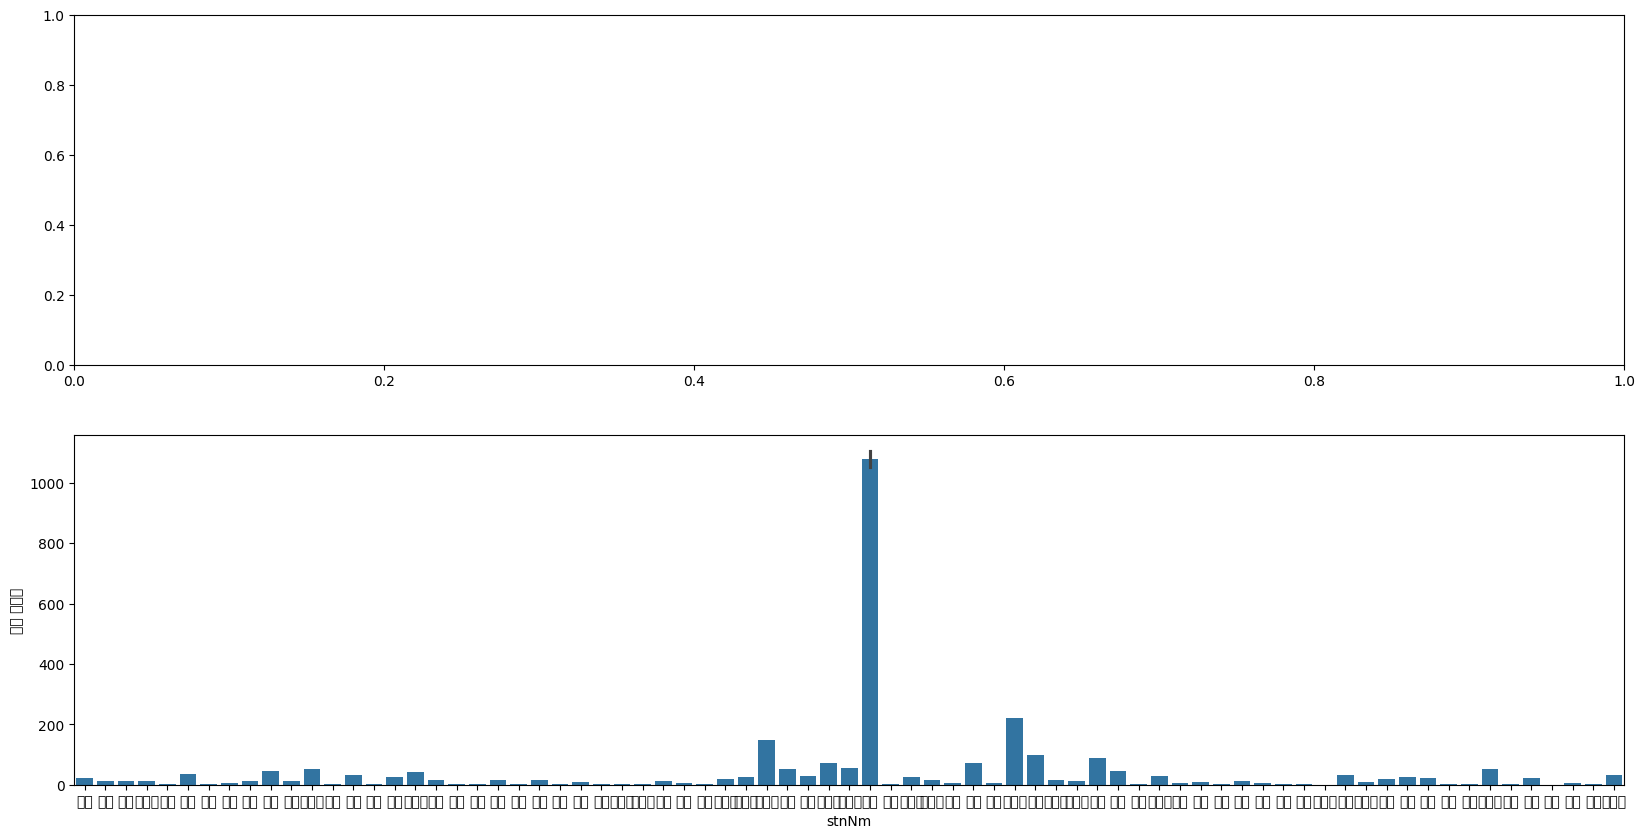

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2,1, figsize=(20,10))
sns.barplot(x = df_all.index, y = df_all["기온 결측치"])

In [ ]:
# 한글 지역명을 영어로 바꾸기 위한 매핑 (예시 일부만 제공하고 필요시 확장 가능)
korean_to_english = {
    "강릉": "Gangneung", "강진군": "Gangjin", "경주시": "Gyeongju", "고산": "Gosan", "고창": "Gochang",
    "고창군": "Gochang-gun", "고흥": "Goheung", "광양시": "Gwangyang", "광주": "Gwangju", "구미": "Gumi",
    "군산": "Gunsan", "금산": "Geumsan", "김해시": "Gimhae", "남원": "Namwon", "남해": "Namhae",
    "대관령": "Daegwallyeong", "대구": "Daegu", "대전": "Daejeon", "동두천": "Dongducheon", "동해": "Donghae",
    "문경": "Mungyeong", "밀양": "Miryang", "보령": "Boryeong", "보성군": "Boseong", "보은": "Boeun",
    "봉화": "Bonghwa", "부산": "Busan", "부안": "Buan", "부여": "Buyeo", "북창원": "Bukchangwon",
    "서귀포": "Seogwipo", "서산": "Seosan", "성산": "Seongsan", "세종": "Sejong", "속초": "Sokcho",
    "수원": "Suwon", "순창군": "Sunchang", "순천": "Suncheon", "안동": "Andong", "양산시": "Yangsan",
    "양평": "Yangpyeong", "영광군": "Yeonggwang", "영월": "Yeongwol", "영주": "Yeongju", "영천": "Yeongcheon",
    "완도": "Wando", "울진": "Uljin", "원주": "Wonju", "의령군": "Uiryeong", "의성": "Uiseong", "이천": "Icheon",
    "인제": "Inje", "임실": "Imsil", "장수": "Jangsu", "장흥": "Jangheung", "전주": "Jeonju",
    "정선군": "Jeongseon", "정읍": "Jeongeup", "제주": "Jeju", "제천": "Jecheon", "진도군": "Jindo",
    "진주": "Jinju", "천안": "Cheonan", "청송군": "Cheongsong", "청주": "Cheongju", "추풍령": "Chupungnyeong",
    "춘천": "Chuncheon", "충주": "Chungju", "태백": "Taebaek", "통영": "Tongyeong", "파주": "Paju",
    "함양군": "Hamyang", "해남": "Haenam", "홍성": "Hongseong", "흑산도": "Heuksando"
}

# 지역명 배열
korean_names = [
    '강릉', '강진군', '경주시', '고산', '고창', '고창군', '고흥', '광양시', '광주', '구미',
    '군산', '금산', '김해시', '남원', '남해', '대관령', '대구', '대전', '동두천', '동해',
    '문경', '밀양', '보령', '보성군', '보은', '봉화', '부산', '부안', '부여', '북창원',
    '서귀포', '서산', '성산', '세종', '속초', '수원', '순창군', '순천', '안동', '양산시',
    '양평', '영광군', '영월', '영주', '영천', '완도', '울진', '원주', '의령군', '의성', '이천',
    '인제', '임실', '장수', '장흥', '전주', '정선군', '정읍', '제주', '제천', '진도군', '진주',
    '천안', '청송군', '청주', '추풍령', '춘천', '충주', '태백', '통영', '파주', '함양군',
    '해남', '홍성', '흑산도'
]

# 매핑 수행
english_names = [korean_to_english.get(name, name) for name in korean_names]

# 결과 출력용 DataFrame
renamed_df = pd.DataFrame({
    "Korean": korean_names,
    "English": english_names
})


In [ ]:
# df_all의 인덱스(지역명)를 영어로 바꾸기
df_all.index = df_all.index.map(korean_to_english).fillna(df_all.index)


TypeError: 'value' must be a scalar, passed: Index

In [ ]:
mapped_index = df_all.index.map(korean_to_english)
df_all.index = mapped_index.where(mapped_index.notnull(), df_all.index)


In [ ]:
df_all

,기온 결측치,습도 결측치,location
stnNm,,,
Boeun,21,20,chungbuk
Jecheon,13,13,chungbuk
Cheongju,13,13,chungbuk
Chupungnyeong,11,11,chungbuk
Chungju,2,5,chungbuk
...,...,...,...
Gochang,1052,1052,jeonbuk
Gwangju,5,4,metropolitan city
Daejeon,1,1,metropolitan city


In [ ]:
seoul1["stnNm"]

0        서울
1        서울
2        서울
3        서울
4        서울
         ..
51139    서울
51140    서울
51141    서울
51142    서울
51143    서울
Name: stnNm, Length: 51144, dtype: object

order                 (2, 0, 2)
seasonal_order    (1, 1, 1, 24)
aic               374635.643963
Name: 167, dtype: object